In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# Pre-Processing Data

## Functions

In [2]:
def load(fnm):
	return json.load(open(fnm))

def pre_proccess_data_from_choice_vs_no_choice(data):
    output = []

    for block_num, block in enumerate(data['blocks']):
        if block_num == 0:
            continue

        try:
            block_drift = block['block_config']['params']['startCameraMode']
        except (KeyError, TypeError):
            block_drift = 0

        game_states = block.get('game_states', {})
        state_times = np.array(game_states.get('time', []))
        ball_y_coords = np.array(game_states.get('ball_y', []))
        camera_y_coords = np.array(game_states.get('camera_y', []))
        
        trials = block['trials']

        for i in range(len(trials) // 3):
            try:
                tier1_event_time = trials[3*i]['events'][0]['time']
                
                if len(state_times) > 0:

                    closest_state_idx = np.abs(state_times - tier1_event_time).argmin()
                    relative_ball_y = float(ball_y_coords[closest_state_idx] - camera_y_coords[closest_state_idx])
                else:
                    relative_ball_y = None


                choice_trial_sequence = [
                    trials[3*i]['hole_locations'],
                    trials[3*i+1]['hole_locations'],
                    trials[3*i+2]['hole_locations']
                ]
                
                chosen_path = [
                    trials[3*i]['events'][0]['holeUsed'], 
                    trials[3*i+1]['events'][0]['holeUsed'],
                    trials[3*i+2]['events'][0]['holeUsed']
                ]
                
                observed_rt = trials[3*i+2]['events'][0]['time'] - trials[3*i]['events'][0]['time']
                
                # does the middle trial have two options
                is_choice = len(trials[3*i+1]['hole_locations']) == 2

                if is_choice:
                    options = trials[3*i+1]['hole_locations']
                    chosen_hole = trials[3*i+1]['events'][0]['holeUsed']
                    
                    unchosen_hole = options[0] if options[0] != chosen_hole else options[1]
                    
                    non_chosen_path = [
                        trials[3*i]['events'][0]['holeUsed'], 
                        unchosen_hole, 
                        trials[3*i+2]['events'][0]['holeUsed']
                    ]
                    
                    chosen_1step_dist = abs(chosen_path[1] - chosen_path[0])
                    unchosen_1step_dist = abs(non_chosen_path[1] - non_chosen_path[0])
                    
                    chosen_2step_dist = chosen_1step_dist + abs(chosen_path[2] - chosen_path[1])
                    unchosen_2step_dist = unchosen_1step_dist + abs(non_chosen_path[2] - non_chosen_path[1])
                    
                else:
                    non_chosen_path = None
                    chosen_1step_dist = None
                    unchosen_1step_dist = None
                    chosen_2step_dist = None
                    unchosen_2step_dist = None
                
                output.append({
                    'block_number': block_num,
                    'trial_sequence_number': i,
                    'hole_sequence': choice_trial_sequence,
                    'chosen_path': chosen_path,
                    'non_chosen_path': non_chosen_path,
                    'observed_rt': observed_rt,
                    'choice_trial': is_choice,
                    'chosen_1step_dist': chosen_1step_dist,
                    'unchosen_1step_dist': unchosen_1step_dist,
                    'chosen_2step_dist': chosen_2step_dist,
                    'unchosen_2step_dist': unchosen_2step_dist,
                    'block_drift': block_drift,
                    'ball_y_at_top': relative_ball_y
                })
            except (KeyError, IndexError, TypeError) as e:
                continue

    output = pd.DataFrame(output)

    Q1 = output['observed_rt'].quantile(0.25)
    Q3 = output['observed_rt'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 2.5 * IQR
    upper_bound = Q3 + 2.5 * IQR
    
    output = output[(output['observed_rt'] >= lower_bound) & (output['observed_rt'] <= upper_bound)]
    output = output.reset_index(drop=True)

    chosen_middle = output['chosen_path'].str[1]
    unchosen_middle = output['non_chosen_path'].str[1]
    output['chosen_left'] = (chosen_middle < unchosen_middle)

    prev_end_hole = output['chosen_path'].shift(1).str[2]
    curr_start_hole = output['chosen_path'].str[0]
    direction = np.sign(prev_end_hole - curr_start_hole)

    prev_seq_num = output['trial_sequence_number'].shift(1)
    curr_seq_num = output['trial_sequence_number']

    prev_block = output['block_number'].shift(1)
    curr_block = output['block_number']

    is_valid_sequence = (prev_seq_num + 1 == curr_seq_num) & (prev_block == curr_block)

    output['incoming_direction'] = np.where(is_valid_sequence, -direction, np.nan)

    output = output.dropna(subset=['incoming_direction']).reset_index(drop=True)

    return output

In [3]:
def prepare_rnn_tensors(raw_data, batch_size=1, test_split=0.2):
    """
    Processes raw maze data and splits it into chronologically separated 
    training and testing dataloaders based on a target percentage of total trials.
    """
    processed_data = pre_proccess_data_from_choice_vs_no_choice(raw_data)
    
    if isinstance(processed_data, list):
        df_raw = pd.DataFrame(processed_data)
    else:
        df_raw = processed_data
        
    is_left = df_raw['chosen_left'].astype(bool)
    
    L1 = np.where(is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    R1 = np.where(~is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    
    chosen_2step_diff = df_raw['chosen_2step_dist'] - df_raw['chosen_1step_dist']
    unchosen_2step_diff = df_raw['unchosen_2step_dist'] - df_raw['unchosen_1step_dist']
    
    L2 = np.where(is_left, chosen_2step_diff, unchosen_2step_diff)
    R2 = np.where(~is_left, chosen_2step_diff, unchosen_2step_diff)

    X = pd.DataFrame({
        'L1-R1': L1 - R1,
        'L2-R2': L2 - R2,
        'block_drift': df_raw['block_drift'],
        'block_number': df_raw['block_number'],
        'chosen_left': df_raw['chosen_left'],
        'cost': df_raw['observed_rt']
    })

    trials_per_block = X.groupby('block_number').size()
    large_blocks = trials_per_block[trials_per_block > 4].index
    
    if not large_blocks.empty:
        first_real_block = large_blocks.min()
        X = X[X['block_number'] >= first_real_block].copy()

    for col in ['L1-R1', 'L2-R2', 'cost']:
        X[col] = pd.to_numeric(X[col], errors='coerce')
        
    X = X.dropna(subset=['L1-R1', 'L2-R2', 'cost', 'chosen_left'])

    max_time = X['cost'].max()
    min_time = X['cost'].min()
    X['cost'] = (X['cost'] - min_time) / (max_time - min_time + 1e-6)

    valid_trials_per_block = X.groupby('block_number').size().sort_index()
    
    if test_split > 0.0:
        cumulative_trials = valid_trials_per_block.cumsum()
        total_trials = cumulative_trials.iloc[-1]
        
        train_threshold = total_trials * (1 - test_split)
        
        train_blocks = set(valid_trials_per_block[cumulative_trials <= train_threshold].index)
        test_blocks = set(valid_trials_per_block[cumulative_trials > train_threshold].index)
        
        if len(test_blocks) == 0 and len(valid_trials_per_block) > 1:
            test_blocks = {valid_trials_per_block.index[-1]}
            train_blocks = set(valid_trials_per_block.index[:-1])
    else:
        train_blocks = set(valid_trials_per_block.index)
        test_blocks = set()

    feature_cols = ['L1-R1', 'L2-R2', 'block_drift']#, 'cost']

    def build_tensors(target_blocks, is_train=True):
        features_list = []
        targets_list = []
        
        for b in sorted(target_blocks):
            group = X[X['block_number'] == b].sort_index()
            features_list.append(torch.tensor(group[feature_cols].values, dtype=torch.float32))
            targets_list.append(torch.tensor(group['chosen_left'].values, dtype=torch.long))
            
        if not features_list:
            return None, None, None
            
        x_pad = pad_sequence(features_list, batch_first=True, padding_value=0.0)
        y_pad = pad_sequence(targets_list, batch_first=True, padding_value=-1)
        
        dataset = TensorDataset(x_pad, y_pad)
        # We usually shuffle training blocks, but keep test blocks sequential for easier evaluation tracking
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
        return x_pad, y_pad, loader

    # Build the distinct loaders
    X_train, y_train, train_loader = build_tensors(train_blocks, is_train=True)
    X_test, y_test, test_loader = build_tensors(test_blocks, is_train=False)

    print(f"-> Extracted {len(train_blocks)} Training Blocks, {len(test_blocks)} Testing Blocks.")
    
    if X_train is not None:
        print(f"-> Train X_padded shape: {X_train.shape} | Train y_padded shape: {y_train.shape}")
    if X_test is not None:
        print(f"-> Test X_padded shape:  {X_test.shape} | Test y_padded shape:  {y_test.shape}")

    # Returns two tuples: one for train, one for test
    return (X_train, y_train, train_loader), (X_test, y_test, test_loader)

## Loading

In [4]:
data = load("cloud study data/65D6694BE06947289BE4336BC1DE271A-019e9464-b9d3-798d-aa65-c87d82961db6-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T21-03-48-346Z-fg8d.json")

In [5]:
processed_data = pd.DataFrame(pre_proccess_data_from_choice_vs_no_choice(data))
processed_data = processed_data[processed_data['block_number'] > 4]

In [6]:
processed_data

,block_number,trial_sequence_number,hole_sequence,chosen_path,non_chosen_path,observed_rt,choice_trial,chosen_1step_dist,unchosen_1step_dist,chosen_2step_dist,unchosen_2step_dist,block_drift,ball_y_at_top,chosen_left,incoming_direction
0,5,1,"[[5], [0, 10], [2]]","[5, 0, 2]","[5, 10, 2]",2801.1,True,5,5,7,13,0,550.408631,True,-0.0
1,5,2,"[[4], [2, 7], [4]]","[4, 7, 4]","[4, 2, 4]",2967.4,True,3,2,6,4,0,516.241611,False,1.0
2,5,3,"[[5], [2, 11], [3]]","[5, 2, 3]","[5, 11, 3]",1950.7,True,3,6,4,14,0,516.271127,True,1.0
3,5,4,"[[4], [2, 11], [6]]","[4, 2, 6]","[4, 11, 6]",2016.5,True,2,7,6,12,0,516.281019,True,1.0
4,5,5,"[[4], [1, 11], [9]]","[4, 11, 9]","[4, 1, 9]",3298.8,True,7,3,9,11,0,516.241813,False,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,36,28,"[[5], [2, 10], [4]]","[5, 2, 4]","[5, 10, 4]",898.8,True,3,5,5,11,1,531.319158,True,-1.0
1026,36,29,"[[8], [3, 11], [6]]","[8, 3, 6]","[8, 11, 6]",1300.0,True,5,3,8,8,1,528.237178,True,1.0
1027,36,30,"[[9], [6, 11], [8]]","[9, 6, 8]","[9, 11, 8]",1916.6,True,3,2,5,5,1,495.278861,True,1.0
1028,36,31,"[[8], [6, 11], [8]]","[8, 6, 8]","[8, 11, 8]",867.8,True,2,3,4,6,1,483.707433,True,-0.0


In [7]:
X = pd.DataFrame({
    'L1': np.where(processed_data['chosen_left'], processed_data['chosen_1step_dist'], processed_data['unchosen_1step_dist']),
    'R1': np.where(~processed_data['chosen_left'], processed_data['chosen_1step_dist'], processed_data['unchosen_1step_dist']),
    
    'L2': np.where(processed_data['chosen_left'], 
                   processed_data['chosen_2step_dist'] - processed_data['chosen_1step_dist'], 
                   processed_data['unchosen_2step_dist'] - processed_data['unchosen_1step_dist']),
    'R2': np.where(~processed_data['chosen_left'], 
                   processed_data['chosen_2step_dist'] - processed_data['chosen_1step_dist'], 
                   processed_data['unchosen_2step_dist'] - processed_data['unchosen_1step_dist']),

    'block_drift': processed_data['block_drift']
})

X = pd.DataFrame({
    'L1-R1': X['L1']-X['R1'],
    'L2-R2': X['L2']-X['R2'],
    'block_drift': X['block_drift'],
    'block_number': processed_data['block_number'],
    'chosen_left': processed_data['chosen_left'],
    'cost': processed_data['observed_rt']
})

In [8]:
X

,L1-R1,L2-R2,block_drift,block_number,chosen_left,cost
0,0,-6,0,5,True,2801.1
1,-1,-1,0,5,False,2967.4
2,-3,-7,0,5,True,1950.7
3,-5,-1,0,5,True,2016.5
4,-4,6,0,5,False,3298.8
...,...,...,...,...,...,...
1025,-2,-4,1,36,True,898.8
1026,2,-2,1,36,True,1300.0
1027,1,-1,1,36,True,1916.6
1028,-1,-1,1,36,True,867.8


# RNNs and Training Functions

In [9]:
class TinyDecisionRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_actions):

        super(TinyDecisionRNN, self).__init__()
        
        self.hidden_size = hidden_size
        
        self.gru = nn.GRU(input_size=input_size, 
                          hidden_size=hidden_size, 
                          batch_first=True)

        self.readout = nn.Linear(in_features=hidden_size, 
                                 out_features=num_actions)

    def forward(self, x, h_0=None):

        gru_out, h_n = self.gru(x, h_0)
        
        logits = self.readout(gru_out)
        
        probabilities = torch.softmax(logits, dim=-1)
        
        return probabilities, h_n
    
def evaluate_model_performance(model, data_loader):
    model.eval()  # Switch model to evaluation mode
    
    total_log_likelihood = 0.0
    all_predictions = []
    all_actuals = []
    
    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            h_0 = torch.zeros(1, batch_x.size(0), model.hidden_size)
            probabilities, _ = model(batch_x, h_0)
            
            for run_idx in range(batch_x.size(0)):
                run_probs = probabilities[run_idx].view(-1, model.readout.out_features)
                run_actuals = batch_y[run_idx].view(-1)
                
                for step_idx in range(run_probs.size(0)):
                    actual_action = run_actuals[step_idx].item()
                    
                    if actual_action == -1:
                        break
                        
                    if actual_action not in [0, 1]:
                        continue
                    
                    try:
                        chosen_prob = run_probs[step_idx][actual_action].item()

                        if np.isnan(chosen_prob) or chosen_prob == 0.0:
                            print(f"Something\'s wrong @ {run_idx}, Step {step_idx}!")
                        total_log_likelihood += np.log(max(chosen_prob, 1e-7))
                        
                        predicted_action = torch.argmax(run_probs[step_idx]).item()
                        
                        all_predictions.append(predicted_action)
                        all_actuals.append(actual_action)
                        
                    except IndexError as e:
                        print(f"Index alignment error at step {step_idx}: {e}")
                        continue
                    
    all_actuals = np.array(all_actuals)
    all_predictions = np.array(all_predictions)
           
    total_steps = len(all_actuals)
    accuracy = np.sum(all_predictions == all_actuals) / total_steps
    err_matrix = confusion_matrix(all_actuals, all_predictions, labels=[0, 1])

    
    return {
        "log_likelihood": total_log_likelihood/total_steps,
        "accuracy": accuracy,
        "error_matrix": err_matrix
    }

def train_RNN(model, train_loader, num_epochs=150, learning_rate=0.005, l1_lambda=1e-4):
    """
    Trains the TinyDecisionRNN model, applying L1 regularization to the 
    recurrent weights and gradient clipping to prevent explosion.
    """

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    

    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    
    model.train()
    
    epoch_losses = []
    
    for epoch in range(num_epochs):
        total_epoch_loss = 0.0
        
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()

            h_0 = torch.zeros(1, batch_x.size(0), model.hidden_size)
            
            gru_out, _ = model.gru(batch_x, h_0)
            logits = model.readout(gru_out) 
            
            logits = logits.view(-1, model.readout.out_features)
            batch_y = batch_y.view(-1)
            
            base_loss = criterion(logits, batch_y)
            
            l1_norm = sum(p.abs().sum() for name, p in model.named_parameters() if 'gru.weight' in name)
            loss = base_loss + (l1_lambda * l1_norm)
            
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            total_epoch_loss += loss.item()
            
        avg_loss = total_epoch_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        
        if (epoch + 1) % 25 == 0:
            print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

    print("\nTraining Complete!")
    return model, epoch_losses

def run_RNN_for_eval(participant_data, num_epochs = 400):
    train_data, test_data = prepare_rnn_tensors(participant_data, batch_size=4, test_split=0.2)
    X_train, y_train, train_loader = train_data
    X_test, y_test, test_loader = test_data

    model_participant = TinyDecisionRNN(input_size=3, hidden_size=2, num_actions=2)
    model_participant, _ = train_RNN(model_participant, train_loader= train_loader, num_epochs= num_epochs)

    return evaluate_model_performance(model_participant, test_loader)

# Logistic Regression Functions

In [39]:
def run_logistic_regression_baseline(X, test_split=0.2):
    """
    Trains a Logistic Regression model as a memoryless baseline, 
    matching the RNN's chronological train/test split and metric outputs.
    """
    #print('run_logistic_regression_baseline input', X.shape)
    valid_trials_per_block = X.groupby('block_number').size().sort_index()
    cumulative_trials = valid_trials_per_block.cumsum()
    total_trials = cumulative_trials.values[-1]
    
    train_threshold = total_trials * (1 - test_split)
    
    train_blocks = valid_trials_per_block[cumulative_trials <= train_threshold].index
    test_blocks = valid_trials_per_block[cumulative_trials > train_threshold].index
    
    if len(test_blocks) == 0 and len(valid_trials_per_block) > 1:
        test_blocks = [valid_trials_per_block.index[-1]]
        train_blocks = valid_trials_per_block.index[:-1]

    train_df = X[X['block_number'].isin(train_blocks)]
    test_df = X[X['block_number'].isin(test_blocks)]
    
    features = [
        'L1-R1', 
        'L2-R2', 
        #'Block Drift', 
        #'Block Drift + L1-R1 Interaction', 
        #'Block Drift + L2-R2 Interaction', 
        'Incoming Direction',
        #'Block Drift + Incoming Direction Interaction',
    ]
    
    X_train = train_df[features]
    y_train = train_df['chosen_left'].astype(int)
    
    X_test = test_df[features]
    y_test = test_df['chosen_left'].astype(int)
    
    if len(X_test) == 0:
        print("❌ Error: No out-of-sample data available for testing.")
        return None

    log_reg = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
    log_reg.fit(X_train, y_train)

    y_pred = log_reg.predict(X_test)
    
    probs = log_reg.predict_proba(X_test)
    
 
    chosen_probs = probs[np.arange(len(y_test)), y_test.values]

    total_log_likelihood = np.sum(np.log(chosen_probs + 1e-15))
    
    accuracy = accuracy_score(y_test, y_pred)
    err_matrix = confusion_matrix(y_test, y_pred, labels=[0, 1])
    total_steps = len(y_test)

    print("\n Predicting probability of going left")
    print("\n Incoming Direction = +1 if they\'re already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction")    

    print("\n Coefficients:")
    for feature, coef in zip(features, log_reg.coef_[0]):
        print(f"  {feature:<25}: {coef:.4f}")
    


    return {
        "model": log_reg,
        "log_likelihood": total_log_likelihood/total_steps,
        "accuracy": accuracy,
        "error_matrix": err_matrix
    }


def evaluate_logistic_baseline(raw_data, test_split=0.2, is_data_raw = True):
    """
    Takes raw participant data, processes all spatial metrics and interaction 
    terms, and evaluates it using a logistic regression baseline model.
    """

    if is_data_raw:
        processed_data = pre_proccess_data_from_choice_vs_no_choice(raw_data)
    else:
        processed_data = raw_data
        
    if isinstance(processed_data, list):
        df_raw = pd.DataFrame(processed_data)
    else:
        df_raw = processed_data
            
    is_left = df_raw['chosen_left'].astype(bool)
        
    L1 = np.where(is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])
    R1 = np.where(~is_left, df_raw['chosen_1step_dist'], df_raw['unchosen_1step_dist'])

    chosen_2step_diff = df_raw['chosen_2step_dist'] - df_raw['chosen_1step_dist']
    unchosen_2step_diff = df_raw['unchosen_2step_dist'] - df_raw['unchosen_1step_dist']

    L2 = np.where(is_left, chosen_2step_diff, unchosen_2step_diff)
    R2 = np.where(~is_left, chosen_2step_diff, unchosen_2step_diff)

    diff_1step_raw = L1 - R1
    diff_2step_raw = L2 - R2
    block_drift = df_raw['block_drift']

    X = pd.DataFrame({
        'diff_1step': diff_1step_raw,
        'diff_2step': diff_2step_raw,
        'Block Drift': block_drift,
        'block_number': df_raw['block_number'],
        'chosen_left': df_raw['chosen_left'].astype(int),
        'Incoming Direction': df_raw['incoming_direction']
    })

    #print('Shape before dropping NaNs:', X.shape)

    #print(X['L1-R1'])

    
    X = X.dropna(subset=['diff_1step', 'diff_2step', 'Block Drift', 'Incoming Direction', 'chosen_left']).copy()

    mean_1 = X['diff_1step'].mean()
    std_1 = X['diff_1step'].std()
    
    mean_2 = X['diff_2step'].mean()
    std_2 = X['diff_2step'].std()

    X['L1-R1'] = (X['diff_1step'] - mean_1) / std_1
    X['L2-R2'] = (X['diff_2step'] - mean_2) / std_2

    X['Block Drift + L1-R1 Interaction'] = X['L1-R1'] * X['Block Drift']
    X['Block Drift + L2-R2 Interaction'] = X['L2-R2'] * X['Block Drift']
    X['Block Drift + Incoming Direction Interaction'] = X['Incoming Direction'] * X['Block Drift']
    X = X.drop(columns=['diff_1step', 'diff_2step'])

    #print('pre process data output', X.shape)

    baseline_results = run_logistic_regression_baseline(X, test_split=test_split)
    
    return baseline_results

# Participant Evals

## Participant 1

In [ ]:
participant1 = load("cloud study data/65D6694BE06947289BE4336BC1DE271A-019e9464-b9d3-798d-aa65-c87d82961db6-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T21-03-48-346Z-fg8d.json")
run_RNN_for_eval(participant1, num_epochs= 400)

In [ ]:
evaluate_logistic_baseline(participant1)

## Participant 2

In [ ]:
participant2 = load("cloud study data/88AD64F00C6B43489770A02E7A1AE2C2-019e8fd9-16e9-7876-8e3b-d51a48df0526-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-03T23-37-31-300Z-4ecm.json")
run_RNN_for_eval(participant2)

In [ ]:
evaluate_logistic_baseline(participant2)

## Participant 3

In [ ]:
participant3 = load("cloud study data/6462D588260B4356936047A04A336EBE-019e9464-f99c-77c5-bf47-327c7a7cf4f1-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T21-41-26-943Z-c5do.json")
run_RNN_for_eval(participant3)

In [ ]:
evaluate_logistic_baseline(participant3)

## Participant 4

In [ ]:
participant4 = load("cloud study data/46331EBA4F494FAD901E83106523FF12-019e9464-9d12-7cc3-8cba-8f0dd00eeb20-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-48-33-792Z-sop6.json")
run_RNN_for_eval(participant4)

In [ ]:
evaluate_logistic_baseline(participant4)

## Participant 5

In [ ]:
participant5 = load("cloud study data/BB4D2ACD4DAB45F5BAB68A472EB2E06C-019e9464-9a85-718c-9964-ec6755cdcd1c-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-48-17-611Z-i0am.json")
run_RNN_for_eval(participant5)

In [ ]:
evaluate_logistic_baseline(participant5)

## Participant 6

In [ ]:
participant6 = load("cloud study data/C47CEEC22AD9448E9F87D0577BA7FC80-019e946e-abeb-723a-8d4d-50881fc0551f-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-59-12-508Z-e1tl.json")
run_RNN_for_eval(participant6)

In [ ]:
evaluate_logistic_baseline(participant6)

## Participant 7

In [ ]:
participant7 = load("cloud study data/CEFD2FE92E6847B2B27FF0175811CE81-019e9464-988c-7240-bf66-336f77c05049-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-50-03-371Z-34zm.json")
run_RNN_for_eval(participant7)

In [ ]:
evaluate_logistic_baseline(participant7)

## Participant 8

In [ ]:
participant8 = load("cloud study data/EC07396CE23248F2855499612FEB8ACA-019e9464-92a5-7d10-b713-7022c5b049fc-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-48-16-501Z-olib.json")
run_RNN_for_eval(participant8)

In [ ]:
evaluate_logistic_baseline(participant8)

## Participant 9

In [ ]:
participant9 = load("cloud study data/FD2A6686546A4D689BE4A684CD264636-019e946a-96b4-78df-ac42-63e6e82c3209-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-54-42-499Z-j7h3.json")
run_RNN_for_eval(participant9)

In [ ]:
evaluate_logistic_baseline(participant9)

# Ball Y Position

<Axes: >

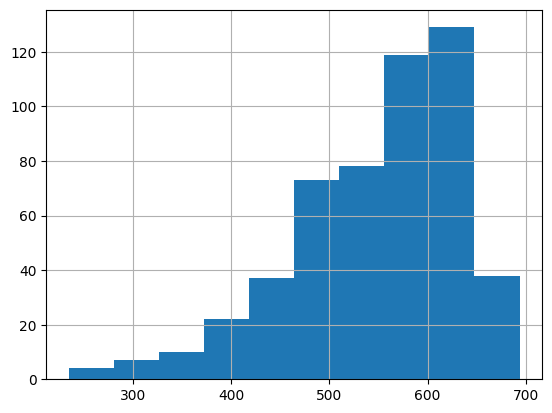

In [45]:
participant1 = load("cloud study data/65D6694BE06947289BE4336BC1DE271A-019e9464-b9d3-798d-aa65-c87d82961db6-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T21-03-48-346Z-fg8d.json")
participant2 = load("cloud study data/88AD64F00C6B43489770A02E7A1AE2C2-019e8fd9-16e9-7876-8e3b-d51a48df0526-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-03T23-37-31-300Z-4ecm.json")
input_data = pre_proccess_data_from_choice_vs_no_choice(participant1)
input_data = input_data[input_data['block_drift'] == 1]
input_data['ball_y_at_top'].hist()

In [46]:
#input_data['ball_y_at_top']
input_data = input_data[input_data['block_drift'] == 1]


LowY = input_data['ball_y_at_top'].quantile(0.25)
HighY = input_data['ball_y_at_top'].quantile(0.75)

# Low pos X means the ball is higher on the screen, ballY - cameraY is smaller

low_pos_X = input_data[(input_data['ball_y_at_top'] < LowY) & (input_data['block_drift'] == 1)]
print(low_pos_X.shape)
high_pos_X = input_data[(input_data['ball_y_at_top'] > HighY) & (input_data['block_drift'] == 1)]
print(high_pos_X.shape)

evaluate_logistic_baseline(low_pos_X, is_data_raw = False)
evaluate_logistic_baseline(high_pos_X, is_data_raw= False)

(129, 15)
(129, 15)

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -2.8475
  L2-R2                    : -0.4851
  Incoming Direction       : 0.5191

 Predicting probability of going left

 Incoming Direction = +1 if they're already going left, and -1 if going right, so the coeffecient represents their bias to going in the same direction

 Coefficients:
  L1-R1                    : -1.9373
  L2-R2                    : -0.6867
  Incoming Direction       : 0.0881


{'model': LogisticRegression(max_iter=1000, penalty=None),
 'log_likelihood': np.float64(-0.3978629634307283),
 'accuracy': 0.84375,
 'error_matrix': array([[13,  2],
        [ 3, 14]])}